# Task 8: Simple Neural Network with PyTorch

**Dataset:** MNIST handwritten digits (via torchvision)  
**Model:** Fully-connected feedforward network (3 layers)  
**Goal:** Train a simple NN from scratch to classify digits 0-9.

Architecture:  
`Input (784) → FC(256, ReLU) → Dropout → FC(128, ReLU) → FC(10, Softmax)`

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}")
print(f"PyTorch: {torch.__version__}")

Using: cpu
PyTorch: 2.13.0+cpu


## Load MNIST Dataset

In [2]:
# normalise pixel values to [-1, 1] using MNIST mean/std
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} samples")
print(f"Test : {len(test_dataset)} samples")

Train: 60000 samples
Test : 10000 samples


## Visualise Some Samples

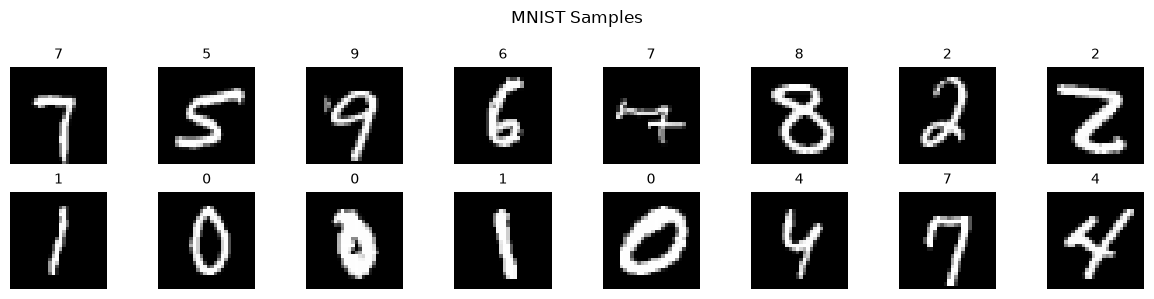

In [3]:
examples = next(iter(train_loader))
images, labels = examples

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for ax, img, lbl in zip(axes.flatten(), images[:16], labels[:16]):
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(str(lbl.item()), fontsize=10)
    ax.axis('off')
plt.suptitle('MNIST Samples', fontsize=12)
plt.tight_layout()
plt.savefig('task8_mnist_samples.png', dpi=100)
plt.show()

## Define the Neural Network

In [4]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),               # 28x28 -> 784
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.3),            # regularisation
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10)          # 10 output classes (logits)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleNN().to(device)
print(model)

# count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

SimpleNN(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

Trainable parameters: 235,146


## Training Loop

In [5]:
criterion = nn.CrossEntropyLoss()   # expects raw logits
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

EPOCHS = 10
train_losses, train_accs, test_accs = [], [], []

def evaluate(loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            preds = model(imgs).argmax(dim=1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)
    return correct / total

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0
    correct, total = 0, 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == lbls).sum().item()
        total += lbls.size(0)

    scheduler.step()
    avg_loss = running_loss / total
    train_acc = correct / total
    test_acc  = evaluate(test_loader)

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%")

Epoch 01/10 | Loss: 0.2773 | Train Acc: 91.55% | Test Acc: 96.41%


Epoch 02/10 | Loss: 0.1360 | Train Acc: 95.79% | Test Acc: 97.11%


Epoch 03/10 | Loss: 0.1041 | Train Acc: 96.69% | Test Acc: 97.68%


Epoch 04/10 | Loss: 0.0896 | Train Acc: 97.17% | Test Acc: 97.83%


Epoch 05/10 | Loss: 0.0773 | Train Acc: 97.55% | Test Acc: 97.70%


Epoch 06/10 | Loss: 0.0523 | Train Acc: 98.33% | Test Acc: 98.23%


Epoch 07/10 | Loss: 0.0441 | Train Acc: 98.60% | Test Acc: 98.06%


Epoch 08/10 | Loss: 0.0415 | Train Acc: 98.64% | Test Acc: 98.19%


Epoch 09/10 | Loss: 0.0382 | Train Acc: 98.73% | Test Acc: 98.13%


Epoch 10/10 | Loss: 0.0362 | Train Acc: 98.78% | Test Acc: 98.26%


## Training Curves

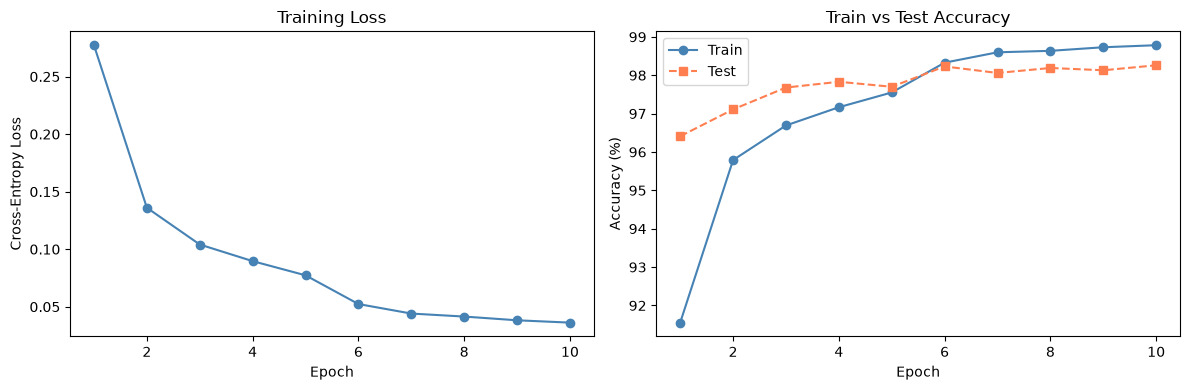


Final Test Accuracy: 98.26%


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, train_losses, 'o-', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss')

ax2.plot(epochs_range, [a*100 for a in train_accs], 'o-', label='Train', color='steelblue')
ax2.plot(epochs_range, [a*100 for a in test_accs],  's--', label='Test',  color='coral')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Train vs Test Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('task8_curves.png', dpi=100)
plt.show()

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

## Show Some Predictions

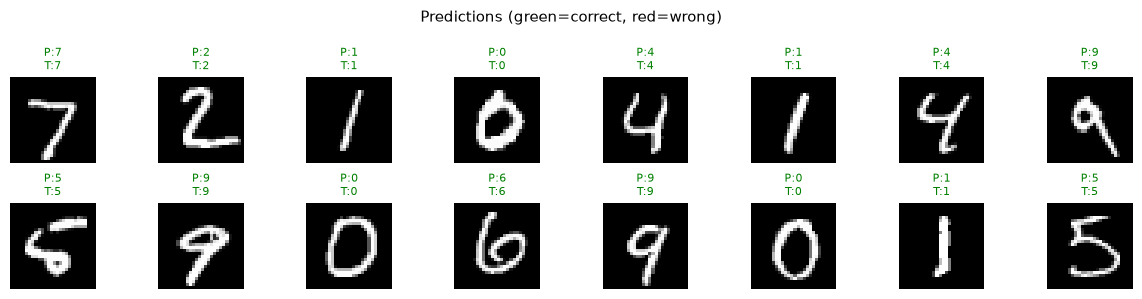

In [7]:
model.eval()
test_images, test_labels = next(iter(test_loader))
with torch.no_grad():
    preds = model(test_images.to(device)).argmax(1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for ax, img, true, pred in zip(axes.flatten(), test_images[:16], test_labels[:16], preds[:16]):
    ax.imshow(img.squeeze(), cmap='gray')
    color = 'green' if true == pred else 'red'
    ax.set_title(f"P:{pred}\nT:{true}", fontsize=8, color=color)
    ax.axis('off')
plt.suptitle('Predictions (green=correct, red=wrong)', fontsize=11)
plt.tight_layout()
plt.savefig('task8_predictions.png', dpi=100)
plt.show()

## Summary

- A simple 3-layer fully connected network achieves **~98% accuracy** on MNIST after 10 epochs.
- Adam optimizer + learning rate decay (StepLR) helped convergence.
- Dropout (0.3) prevents overfitting — train and test accuracy stay close.
- Training on CPU takes a few minutes; on GPU it would be under 1 minute.
- For even better results, a Convolutional Neural Network (CNN) would be the natural next step.